In [1]:
import pandas as pd

crop = "무"  # 작물 이름 변경
# df = pd.read_csv(f"../data/{crop}_lag_인코딩스케일링완료.csv", encoding='cp949')
df = pd.read_csv(f"../data/{crop}(EDA용)_스케일링만.csv", encoding='cp949')

In [2]:
df.columns

Index(['year', 'week', 'week_start', '품종코드', '등급코드', '직팜산지코드', '총거래량(kg)',
       '일평균기온', '최고기온', '최저기온', '평균상대습도', '강수량(mm)', '1시간최고강수량(mm)',
       'holiday_flag', 'holiday_score', 'grow_score', '평균단가(원)', '일평균기온_t-1',
       '최고기온_t-1', '최저기온_t-1', '평균상대습도_t-1', '강수량(mm)_t-1', '1시간최고강수량(mm)_t-1',
       '일평균기온_t-2', '최고기온_t-2', '최저기온_t-2', '평균상대습도_t-2', '강수량(mm)_t-2',
       '1시간최고강수량(mm)_t-2', '일평균기온_t-3', '최고기온_t-3', '최저기온_t-3', '평균상대습도_t-3',
       '강수량(mm)_t-3', '1시간최고강수량(mm)_t-3', '일평균기온_t-4', '최고기온_t-4', '최저기온_t-4',
       '평균상대습도_t-4', '강수량(mm)_t-4', '1시간최고강수량(mm)_t-4'],
      dtype='object')

In [3]:
# 결측치 확인
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]

# 출력
if missing_cols.empty:
    print("결측치 없음!")
else:
    print("결측치 있는 컬럼:")
    print(missing_cols)


결측치 없음!


In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

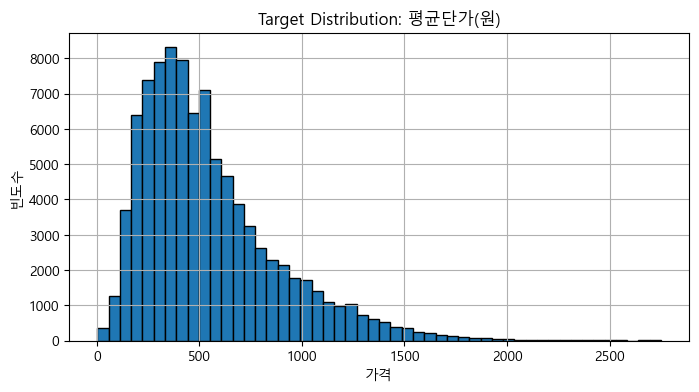

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df['평균단가(원)'], bins=50, edgecolor='k')
plt.title("Target Distribution: 평균단가(원)")
plt.xlabel("가격")
plt.ylabel("빈도수")
plt.grid(True)
plt.show()


In [6]:
correlations = df.corr(numeric_only=True)['평균단가(원)'].sort_values(ascending=False)
print("📊 평균단가와 상관관계가 높은 변수 Top 10:")
print(correlations.drop('평균단가(원)').head(10))


📊 평균단가와 상관관계가 높은 변수 Top 10:
year         0.220422
최저기온_t-3     0.148309
최저기온_t-4     0.146637
일평균기온_t-4    0.141868
일평균기온_t-3    0.139206
최고기온_t-4     0.135023
최저기온_t-2     0.132220
최고기온_t-3     0.131527
일평균기온_t-2    0.126960
최고기온_t-2     0.124319
Name: 평균단가(원), dtype: float64


C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\1338627807.py:21: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


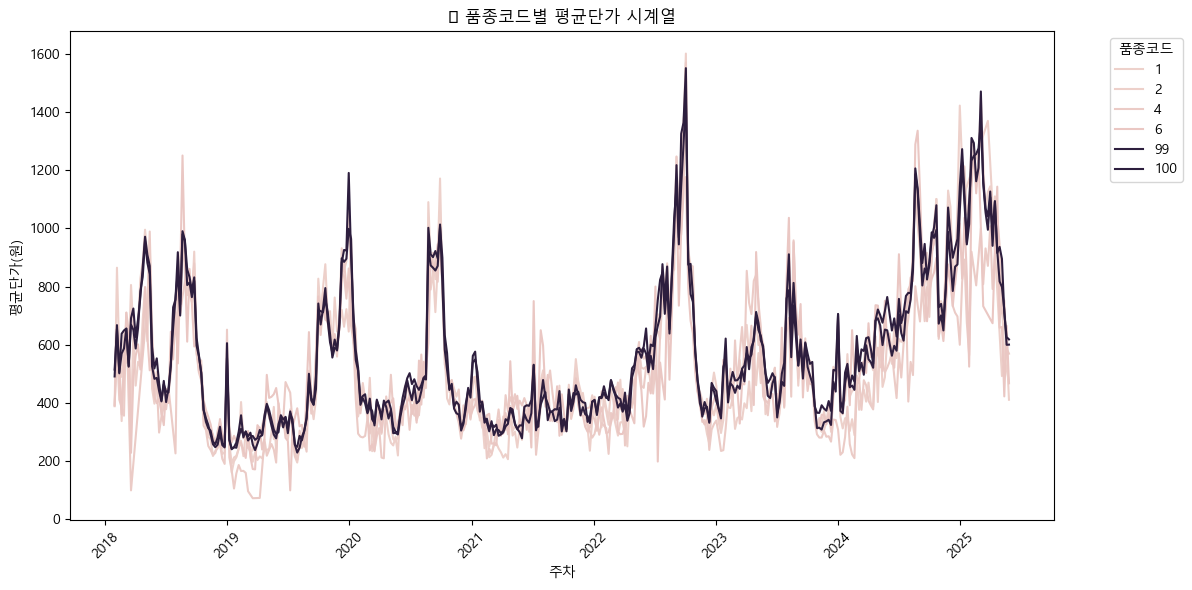

C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\1338627807.py:32: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


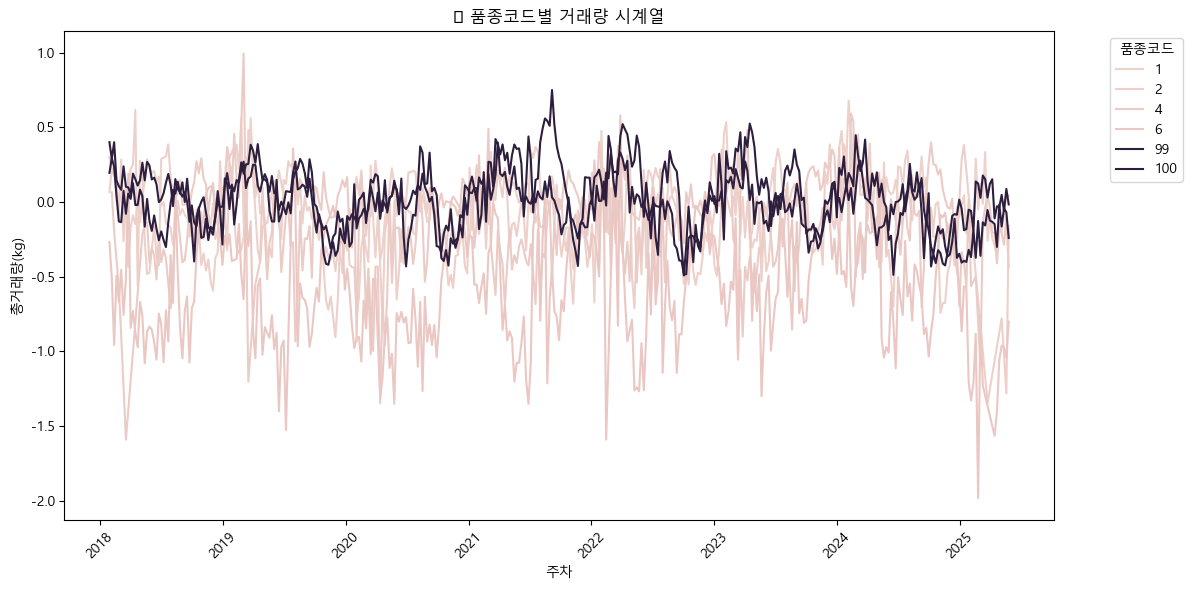

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# 날짜형 변환
df['week_start'] = pd.to_datetime(df['week_start'])

# 🔄 주차별 품종코드 기준 평균 계산
df_grouped = df.groupby(['week_start', '품종코드']).agg({
    '평균단가(원)': 'mean',
    '총거래량(kg)': 'mean'
}).reset_index()

# 🎨 품종별 평균단가 시계열 그래프
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='week_start', y='평균단가(원)', hue='품종코드')
plt.title("📈 품종코드별 평균단가 시계열")
plt.xlabel("주차")
plt.ylabel("평균단가(원)")
plt.xticks(rotation=45)
plt.legend(title='품종코드', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 🎨 품종별 거래량 시계열 그래프
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_grouped, x='week_start', y='총거래량(kg)', hue='품종코드')
plt.title("📦 품종코드별 거래량 시계열")
plt.xlabel("주차")
plt.ylabel("총거래량(kg)")
plt.xticks(rotation=45)
plt.legend(title='품종코드', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\570080950.py:9: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


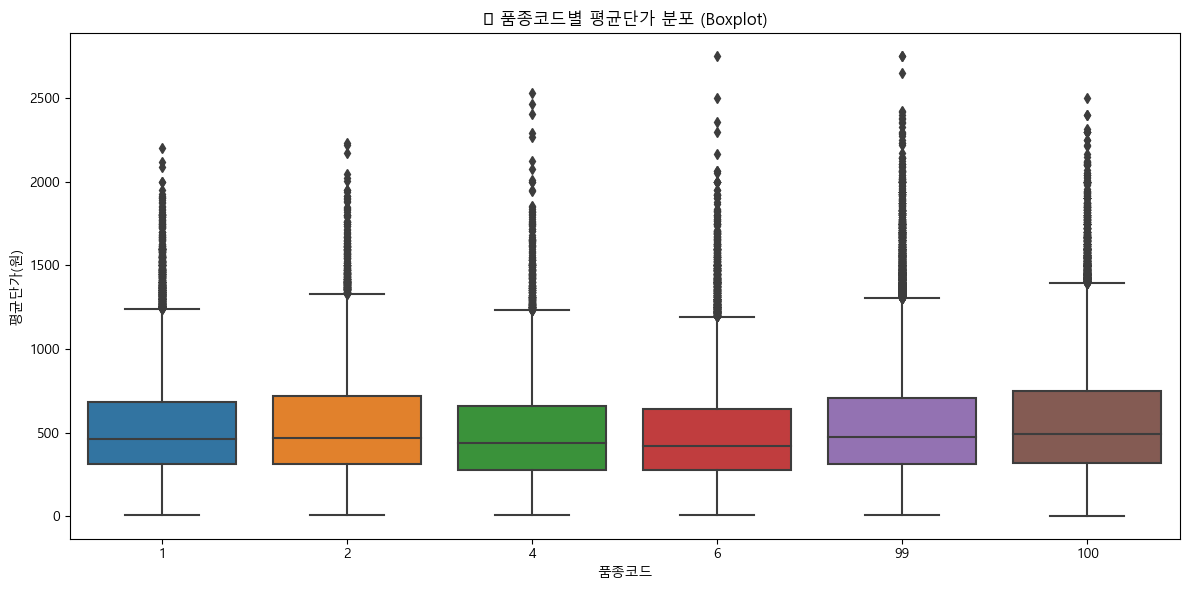

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='품종코드', y='평균단가(원)')
plt.title("📦 품종코드별 평균단가 분포 (Boxplot)")
plt.xlabel("품종코드")
plt.ylabel("평균단가(원)")
plt.tight_layout()
plt.show()


C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\420509624.py:6: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


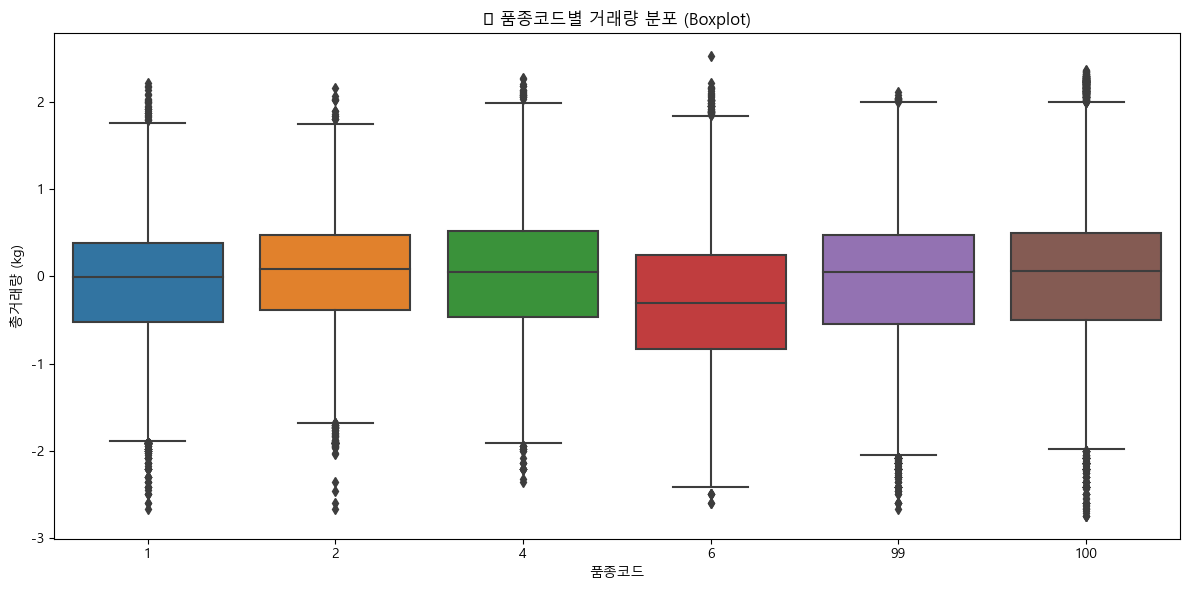

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='품종코드', y='총거래량(kg)')
plt.title("🚚 품종코드별 거래량 분포 (Boxplot)")
plt.xlabel("품종코드")
plt.ylabel("총거래량 (kg)")
plt.tight_layout()
plt.show()


C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\2565174899.py:7: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


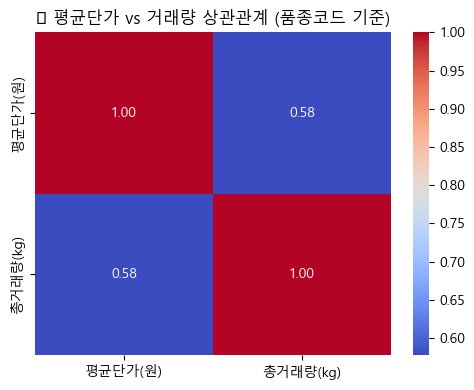

In [10]:
# 품종코드별 평균 요약
pivot_df = df.groupby('품종코드')[['평균단가(원)', '총거래량(kg)']].mean().corr()

plt.figure(figsize=(5, 4))
sns.heatmap(pivot_df, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("📊 평균단가 vs 거래량 상관관계 (품종코드 기준)")
plt.tight_layout()
plt.show()


C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\1619037098.py:35: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


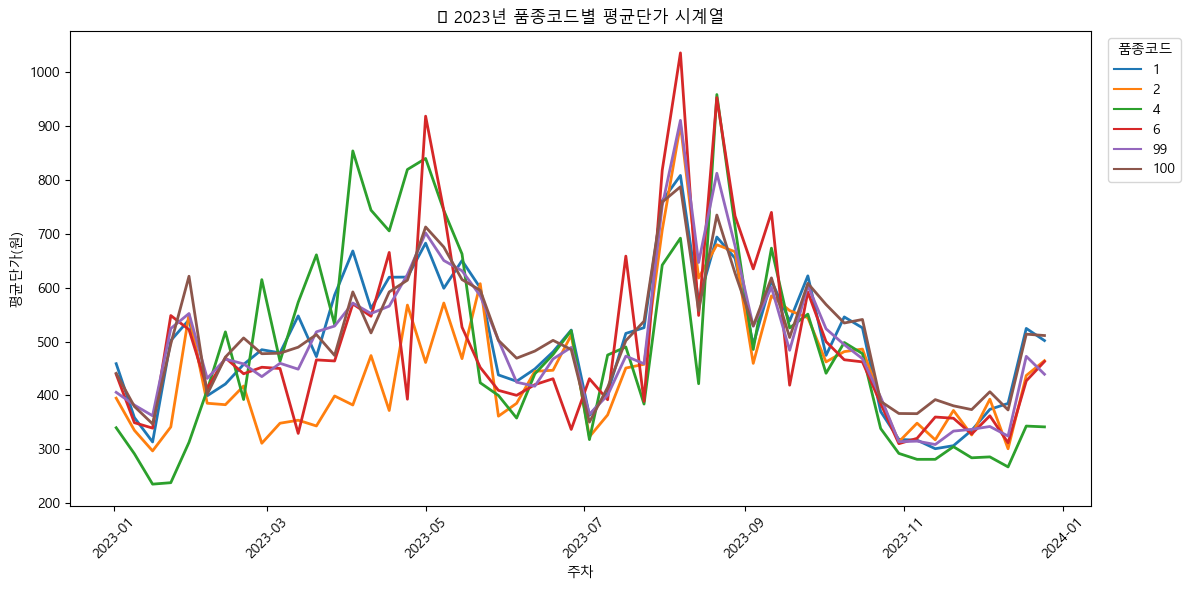

C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\1619037098.py:53: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


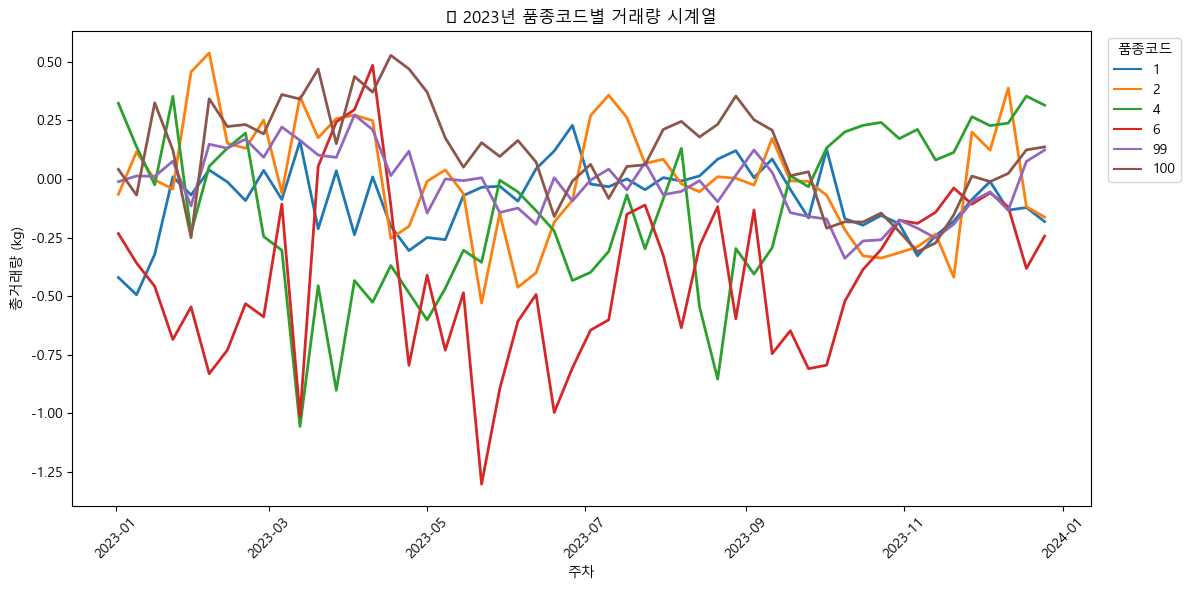

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 날짜 변환
df['week_start'] = pd.to_datetime(df['week_start'])

# 2023년 필터링
df_2023 = df[df['week_start'].dt.year == 2023]

# 품종코드별 평균 계산
df_grouped = df_2023.groupby(['week_start', '품종코드']).agg({
    '평균단가(원)': 'mean',
    '총거래량(kg)': 'mean'
}).reset_index()

# 🎨 색상: 분리 명확한 팔레트 사용 (예: tab10 또는 Set2)
palette = sns.color_palette("tab10", n_colors=6)

# ✅ 평균단가 시계열
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_grouped,
    x='week_start',
    y='평균단가(원)',
    hue='품종코드',
    palette=palette,
    linewidth=2
)
plt.title("📈 2023년 품종코드별 평균단가 시계열")
plt.xlabel("주차")
plt.ylabel("평균단가(원)")
plt.xticks(rotation=45)
plt.legend(title='품종코드', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ✅ 거래량 시계열
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_grouped,
    x='week_start',
    y='총거래량(kg)',
    hue='품종코드',
    palette=palette,
    linewidth=2
)
plt.title("📦 2023년 품종코드별 거래량 시계열")
plt.xlabel("주차")
plt.ylabel("총거래량 (kg)")
plt.xticks(rotation=45)
plt.legend(title='품종코드', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\3289101830.py:13: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


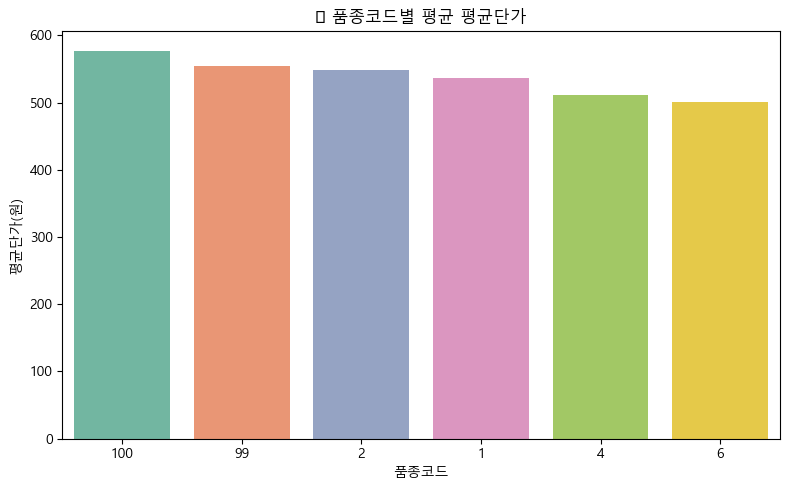

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# 품종별 평균단가 요약
mean_price_by_crop = df.groupby('품종코드')['평균단가(원)'].mean().sort_values(ascending=False)

# 시각화
plt.figure(figsize=(8, 5))
sns.barplot(x=mean_price_by_crop.index.astype(str), y=mean_price_by_crop.values, palette='Set2')
plt.title("📊 품종코드별 평균 평균단가")
plt.xlabel("품종코드")
plt.ylabel("평균단가(원)")
plt.tight_layout()
plt.show()


C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\2618507965.py:6: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


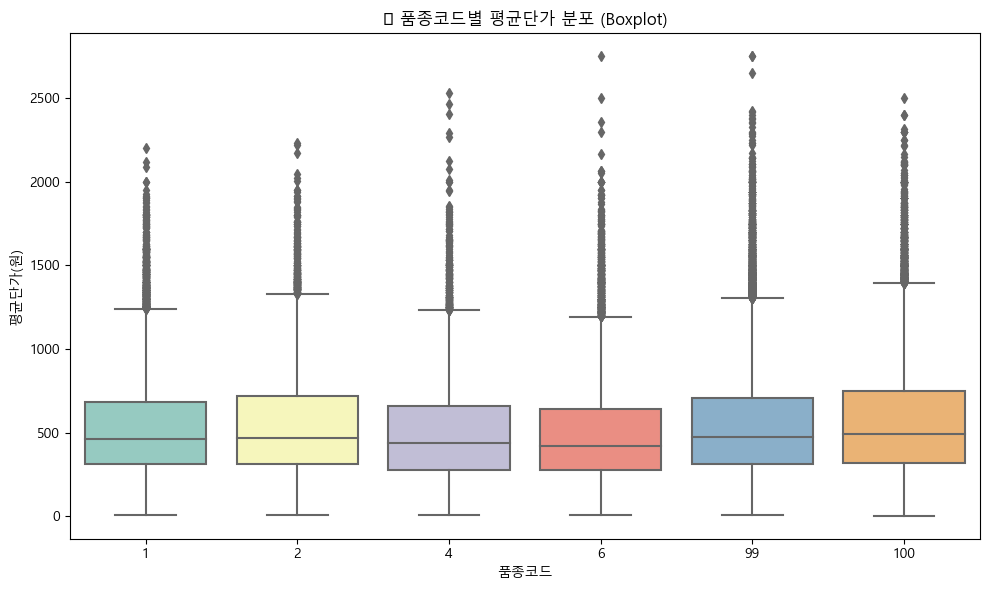

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='품종코드', y='평균단가(원)', palette='Set3')
plt.title("📦 품종코드별 평균단가 분포 (Boxplot)")
plt.xlabel("품종코드")
plt.ylabel("평균단가(원)")
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 상관계수 계산 대상: 평균단가/거래량과 lag 변수만 추출
target_cols = ['평균단가(원)', '총거래량(kg)']
lag_features = [col for col in df.columns if '_t-' in col]

# 대상 + 타겟 결합
corr_df = df[lag_features + target_cols].corr()

# 평균단가와의 상관계수 추출
corr_price = corr_df.loc[lag_features, '평균단가(원)']
corr_volume = corr_df.loc[lag_features, '총거래량(kg)']

# 데이터프레임 형태로 정리
corr_result = pd.DataFrame({
    '기상변수_lag': lag_features,
    '평균단가_corr': corr_price.values,
    '거래량_corr': corr_volume.values
})

# 변수명 분리
corr_result['기상변수'] = corr_result['기상변수_lag'].str.extract(r'(.*?)_t-')
corr_result['lag'] = corr_result['기상변수_lag'].str.extract(r'_t-(\d)').astype(int)


C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\2962757706.py:7: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  plt.tight_layout()
C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\2962757706.py:7: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


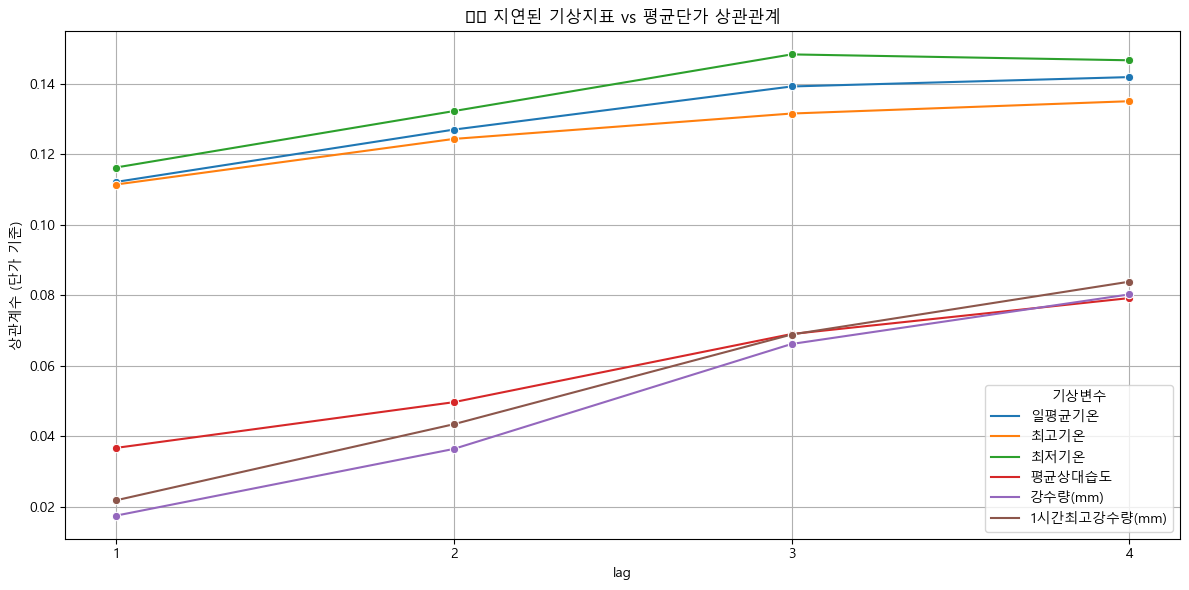

C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\2962757706.py:16: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  plt.tight_layout()
C:\Users\bdh99\AppData\Local\Temp\ipykernel_13912\2962757706.py:16: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  plt.tight_layout()
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\bdh99\anaconda3\envs\jikfam\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


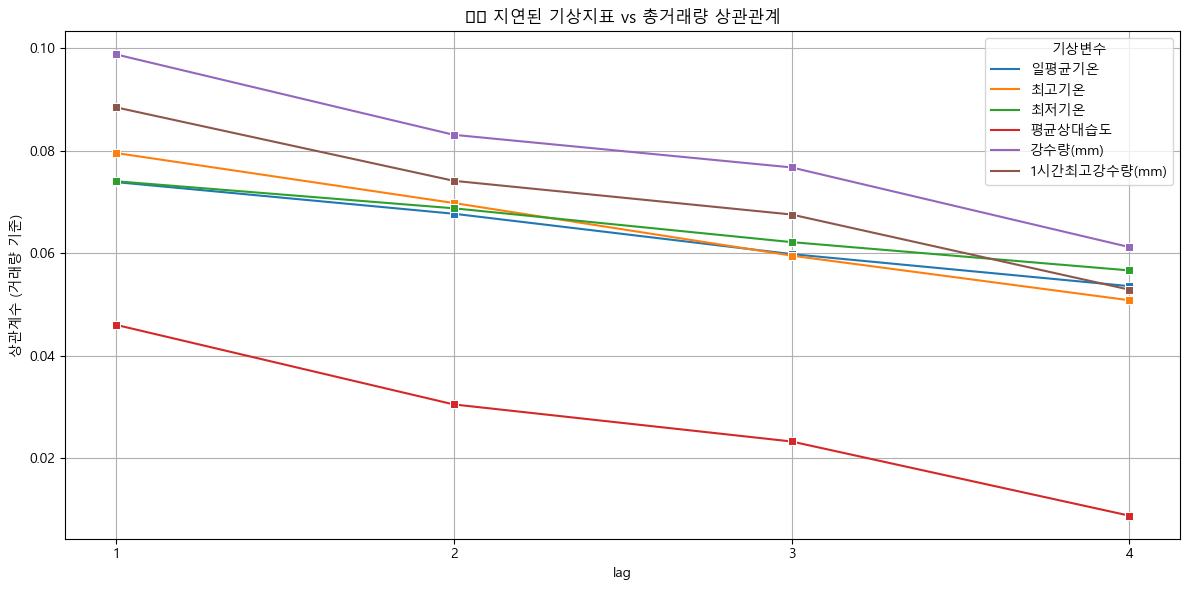

In [19]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_result, x='lag', y='평균단가_corr', hue='기상변수', marker='o')
plt.title("⏱️ 지연된 기상지표 vs 평균단가 상관관계")
plt.ylabel("상관계수 (단가 기준)")
plt.xticks([1, 2, 3, 4])
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_result, x='lag', y='거래량_corr', hue='기상변수', marker='s')
plt.title("⏱️ 지연된 기상지표 vs 총거래량 상관관계")
plt.ylabel("상관계수 (거래량 기준)")
plt.xticks([1, 2, 3, 4])
plt.grid(True)
plt.tight_layout()
plt.show()


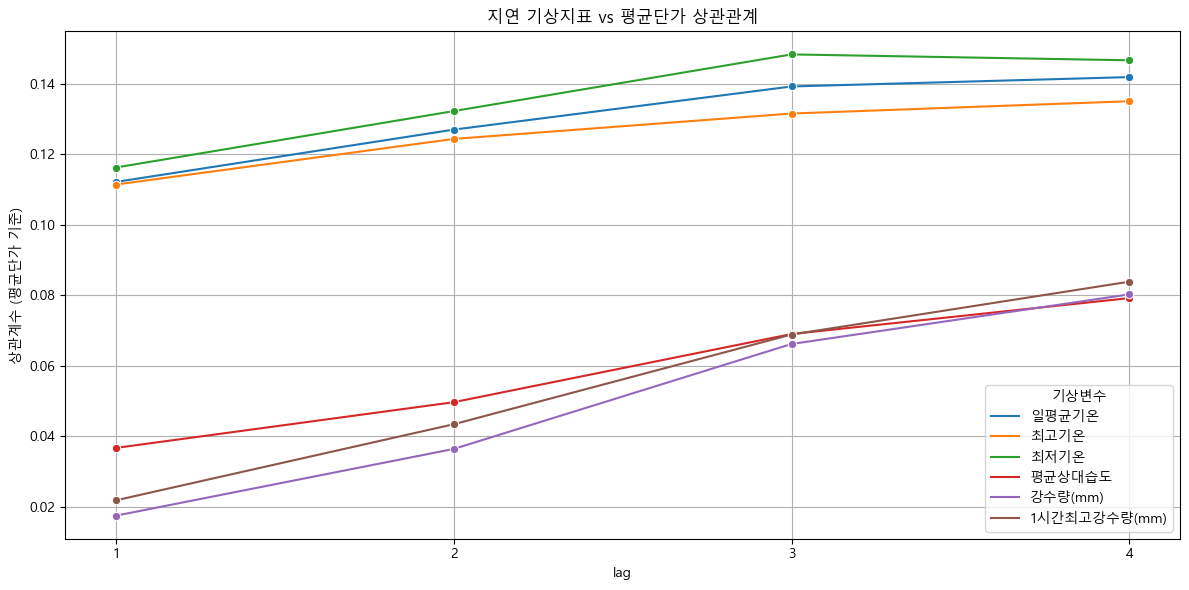

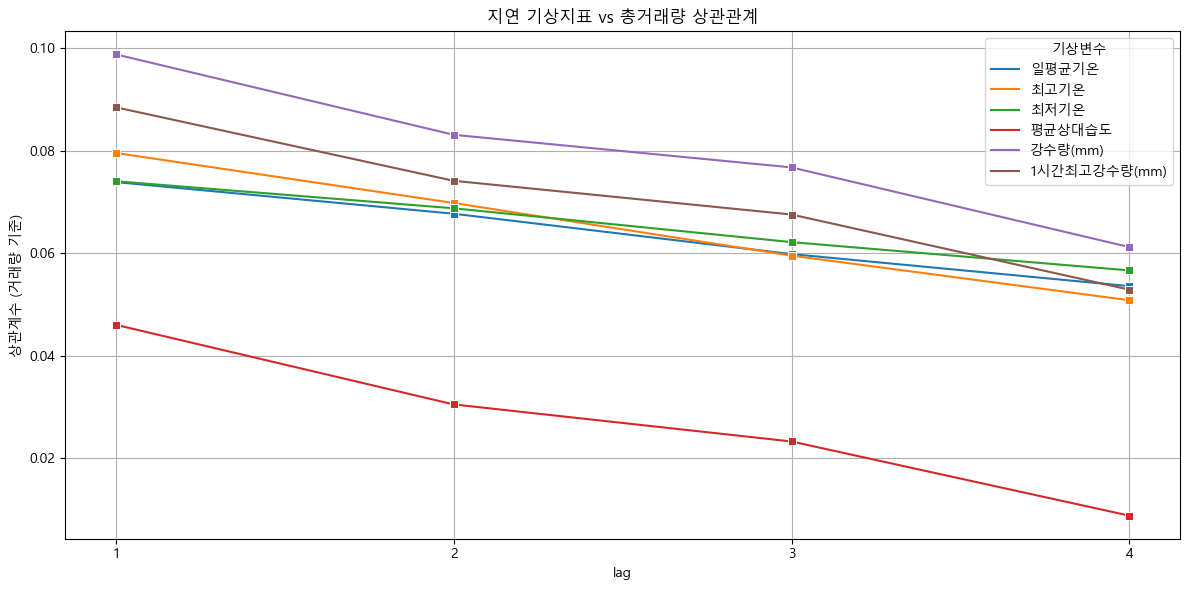

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🎯 타겟 변수
target_cols = ['평균단가(원)', '총거래량(kg)']

# 🎯 lag 변수 추출 (ex: '일평균기온_t-1', '강수량(mm)_t-3', ...)
lag_features = [col for col in df.columns if '_t-' in col]

# ✅ 상관계수 계산
corr_df = df[lag_features + target_cols].corr()

# 상관계수 추출
corr_price = corr_df.loc[lag_features, '평균단가(원)']
corr_volume = corr_df.loc[lag_features, '총거래량(kg)']

# ✅ 정리된 결과 테이블
corr_result = pd.DataFrame({
    '기상변수_lag': lag_features,
    '평균단가_corr': corr_price.values,
    '거래량_corr': corr_volume.values
})
corr_result['기상변수'] = corr_result['기상변수_lag'].str.extract(r'(.*?)_t-')
corr_result['lag'] = corr_result['기상변수_lag'].str.extract(r'_t-(\d+)').astype(int)

# ✅ 평균단가 상관관계 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_result, x='lag', y='평균단가_corr', hue='기상변수', marker='o')
plt.title("지연 기상지표 vs 평균단가 상관관계")
plt.ylabel("상관계수 (평균단가 기준)")
plt.xticks([1, 2, 3, 4])
plt.grid(True)
plt.tight_layout()
plt.show()

# ✅ 거래량 상관관계 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_result, x='lag', y='거래량_corr', hue='기상변수', marker='s')
plt.title("지연 기상지표 vs 총거래량 상관관계")
plt.ylabel("상관계수 (거래량 기준)")
plt.xticks([1, 2, 3, 4])
plt.grid(True)
plt.tight_layout()
plt.show()
